# Exploratory Data Analysis

The main purpose of this notebook is to provide a further exploratory data analysis of the processed datasets.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

DATA_S1_PATH = PROJECT_ROOT / "data" / "processed" / "processed-s1.csv"
DATA_S2_PATH = PROJECT_ROOT / "data" / "processed" / "processed-s2.csv"

EXPORT_PATH = PROJECT_ROOT / "figures"

data_s1 = pd.read_csv(DATA_S1_PATH)
data_s2 = pd.read_csv(DATA_S2_PATH)

### EDA Dataset S1

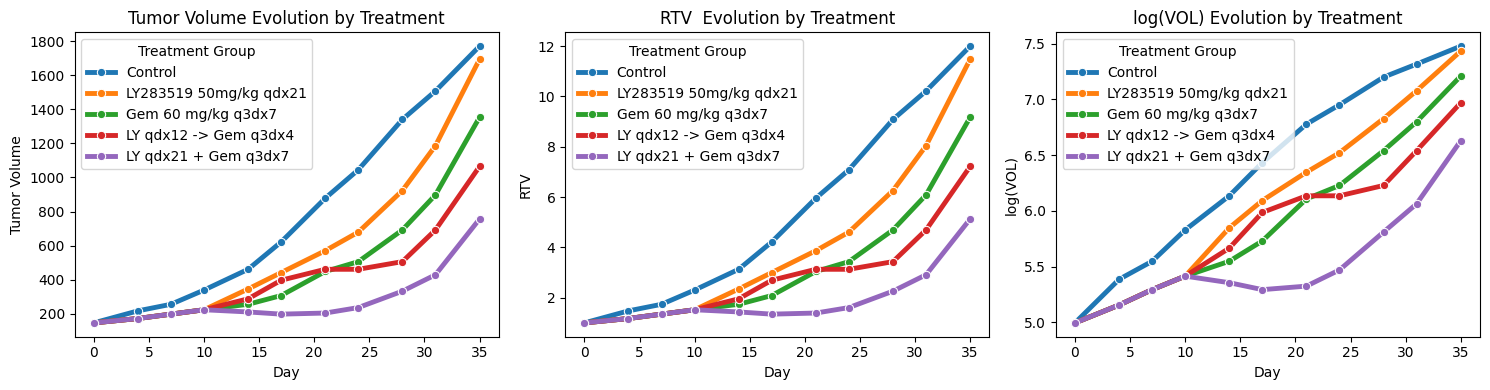

In [2]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Volume vs Days
sns.lineplot(
    data=data_s1,
    x="DAYS",
    y="VOL",
    hue="TRT",
    linewidth=3.5,  
    marker="o",
    markersize=6,
    ax=ax1
)
ax1.set_title("Tumor Volume Evolution by Treatment")
ax1.set_xlabel("Day")
ax1.set_ylabel("Tumor Volume")
ax1.legend(title="Treatment Group", loc="upper left", frameon=True)


# RTV vs Days
sns.lineplot(
    data=data_s1,
    x="DAYS",
    y="RTV",
    hue="TRT",
    linewidth=3.5,  
    marker="o",
    markersize=6,
    ax=ax2
)
ax2.set_title("RTV  Evolution by Treatment")
ax2.set_xlabel("Day")
ax2.set_ylabel("RTV")
ax2.legend(title="Treatment Group", loc="upper left", frameon=True)


# log(VOL) vs Days
sns.lineplot(
    data=data_s1,
    x="DAYS",
    y="LOGVOL",
    hue="TRT",
    linewidth=3.5,  
    marker="o",
    markersize=6,
    ax=ax3
)
ax3.set_title("log(VOL) Evolution by Treatment")
ax3.set_xlabel("Day")
ax3.set_ylabel("log(VOL)")
ax3.legend(title="Treatment Group", loc="upper left", frameon=True)

ax3.get_figure().savefig(EXPORT_PATH / "fig1", dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()

The evolution of variables VOL (tumor volume) RTV (Relative Tumor Volume) and LOGVOL (logarithm of the tumor volume) has been ploted against the number of days. The following is observed:

- Since RTV is only a normalization of raw volume, treatments on both graphs follow the same trajectory.
- The tumor volume of the control group is consistenly the highest and exhibits an approximately exponential growth. Nevertheless, growth appears to become linear as days pass (although the slope of the line is still very steep).
- In general it can be observed that treatment does not reduce the volume of the tumors, it just reduces the rate of growth. During the first 20-25 days the treatments manage to suppress the growth of the tumors, although since then tumor volume augments dramatically for all treated groups (which might indicate acquired treatment resistance).
- All groups present roughly monotonous behavior except for treatment *LY qdx21 + Gem q3dx7*, which has a slight descent in volume at around days 15-20 before ascending again in an exponential way.   

Next it will be analyzed whether tumor growth rates are stable or present high variations for the different treatment groups. 

In [3]:
data_s1["delta_RTV"] = data_s1.groupby("ID")["RTV"].diff()
data_s1["delta_t"] = data_s1.groupby("ID")["DAYS"].diff()
data_s1["r"] = data_s1["delta_RTV"] / data_s1["delta_t"]

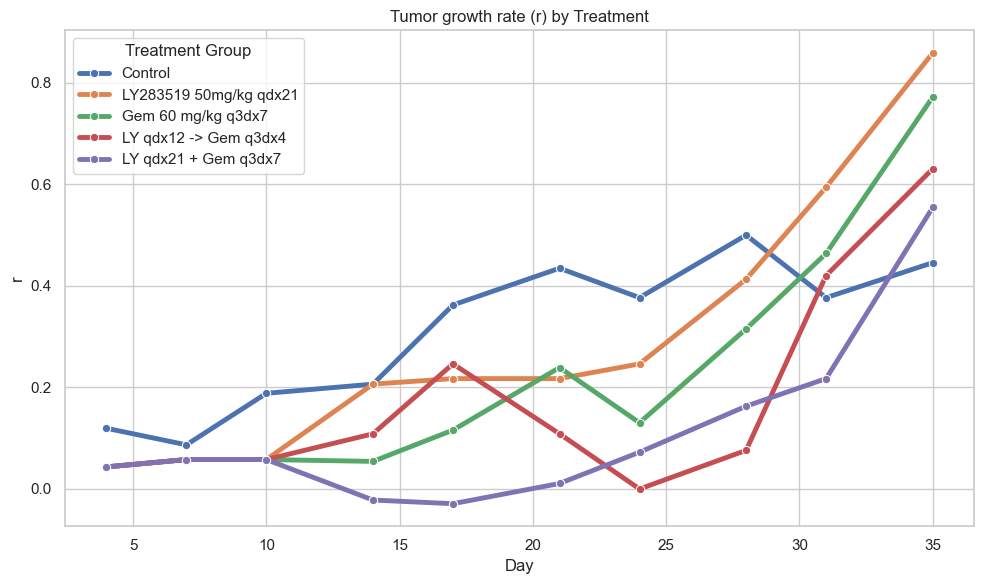

In [4]:
plot_df = data_s1.dropna(subset=["r"]).copy()

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=plot_df,
    x="DAYS",
    y="r",
    hue="TRT",
    linewidth=3.5,  
    marker="o",
    markersize=6,
    ax=ax
)
ax.set_title("Tumor growth rate (r) by Treatment")
ax.set_xlabel("Day")
ax.set_ylabel("r")
ax.legend(title="Treatment Group", loc="upper left", frameon=True)

ax.get_figure().savefig(EXPORT_PATH / "fig2", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

It seems clear that the growth rate (r) is not constant as it increases from near 0 to almost 0.85.

### EDA Dataset S2

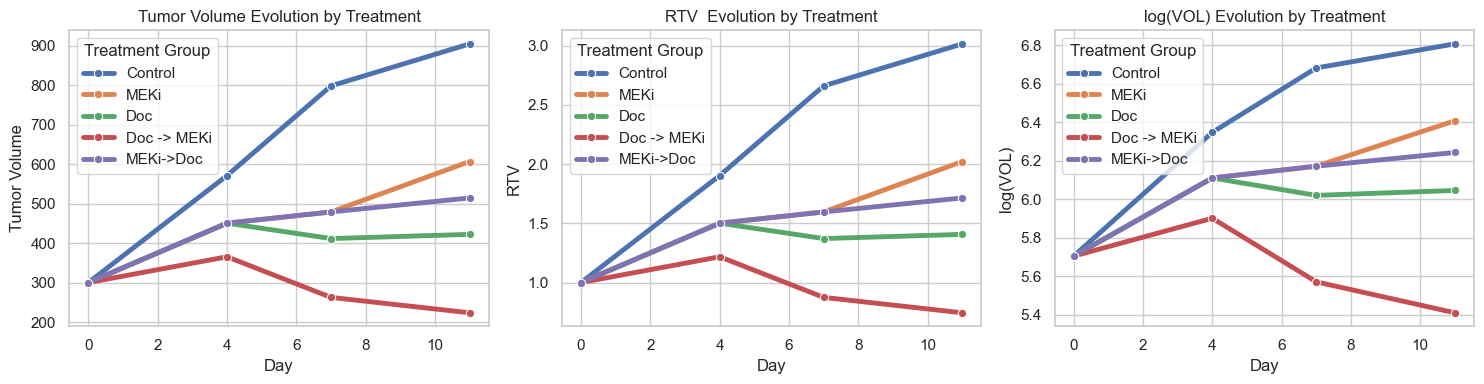

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Volume vs Days
sns.lineplot(
    data=data_s2,
    x="DAYS",
    y="VOL",
    hue="TRT",
    linewidth=3.5,  
    marker="o",
    markersize=6,
    ax=ax1
)
ax1.set_title("Tumor Volume Evolution by Treatment")
ax1.set_xlabel("Day")
ax1.set_ylabel("Tumor Volume")
ax1.legend(title="Treatment Group", loc="upper left", frameon=True)


# RTV vs Days
sns.lineplot(
    data=data_s2,
    x="DAYS",
    y="RTV",
    hue="TRT",
    linewidth=3.5,  
    marker="o",
    markersize=6,
    ax=ax2
)
ax2.set_title("RTV  Evolution by Treatment")
ax2.set_xlabel("Day")
ax2.set_ylabel("RTV")
ax2.legend(title="Treatment Group", loc="upper left", frameon=True)


# log(VOL) vs Days
sns.lineplot(
    data=data_s2,
    x="DAYS",
    y="LOGVOL",
    hue="TRT",
    linewidth=3.5,  
    marker="o",
    markersize=6,
    ax=ax3
)
ax3.set_title("log(VOL) Evolution by Treatment")
ax3.set_xlabel("Day")
ax3.set_ylabel("log(VOL)")
ax3.legend(title="Treatment Group", loc="upper left", frameon=True)

ax3.get_figure().savefig(EXPORT_PATH / "fig3", dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()

Once again, the evolution of variables VOL (tumor volume) RTV (Relative Tumor Volume) and LOGVOL (logarithm of the tumor volume) has been ploted against the number of days. The following is observed:

- The control group is consistently the group with highest tumor volume (and therefore highest RTV and log(VOL)). It exhibits a linear growth, with a slight decrease in the slope at the last time step (perhaps due to saturation, tumors cannot infinitelly grow inside an organism.
- In this case no exponential growth is observed for any of the groups, although this might be due to the fact that this dataset only contains 4 samples for each group.
- In this case treatments *Doc -> MEKi* and *MEKi -> Doc* managed to consistently reduce the volume of the tumors and do not present a monotonous behavior.

In [6]:
data_s2["delta_RTV"] = data_s2.groupby("ID")["RTV"].diff()
data_s2["delta_t"] = data_s2.groupby("ID")["DAYS"].diff()
data_s2["r"] = data_s2["delta_RTV"] / data_s1["delta_t"]

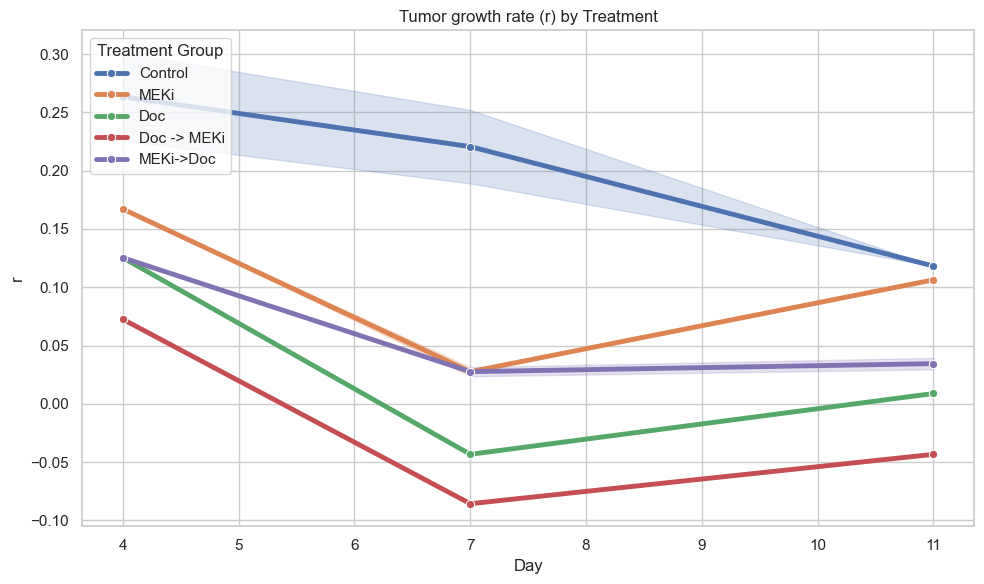

In [7]:
plot_df = data_s2.dropna(subset=["r"]).copy()

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=plot_df,
    x="DAYS",
    y="r",
    hue="TRT",
    linewidth=3.5,  
    marker="o",
    markersize=6,
    ax=ax
)
ax.set_title("Tumor growth rate (r) by Treatment")
ax.set_xlabel("Day")
ax.set_ylabel("r")
ax.legend(title="Treatment Group", loc="upper left", frameon=True)

ax.get_figure().savefig(EXPORT_PATH / "fig4", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

The assumption of a constant r is feasible for days 7-11, since it is virtually flat among almost all groups. However, during the first few days growth rate descents clearly for all groups.

### Limitations

During the EDA it has been observed the following limitations regarding the model:

- Some groups do not exhibit a monotonous behavior, which is not captured in the model used. Since the parameters for growth ($r$), max size ($K$) and drug effectiveness ($\alpha$) are locked in as constant numbers the evolution must be monotonous: if drug killing power is higher than growth, the formula forces the tumor size to strictly go down, however if drug killing power is lower (or zero, in the case of the control group), the formula forces the tumor size to strictly augment. For this reason, it seems like the first dataset will be a best fit for the studied model.
- It seems clear that a constant $r$ is not feasible for these datasets. Moreover, each dataset presents a unique response to treatments and therefore it might be difficult to work with both datasets using the same model. 

### Decisions

Taking all the above into consideration, it has been decided that the second dataset will be disregarded for this project because of the mentioned issues and the lack of sufficient data.

To address the problem of non constant $r$, the initial model will be expanded by incorporating tumor cell resistance. It has been observed that during the first days the treatments managed to control tumor growth, however after sufficient time had passed all treated groups experienced a sharp growth in tumor volume. This is probably due to the fact that some tumor cells develop resistance to the treatment.

The new proposed model solves this issue by tracking two distinct cell sub-populations simultaneously: a drug-sensitive population ($T_s$) and a drug-resistant population ($T_r$).

$$T_{s,t+1}=T_{s,t} + r_s · T_{s,t}(1 - \frac{T_{s,t} + T_{r,t}}{K}) - \alpha · D_t · T_{s,t} - \mu · T_{s,t}$$
$$T_{r,t+1}=T_{s,t} + r_r · T_{r,t}(1 - \frac{T_{s,t} + T_{r,t}}{K}) + \mu · T_{s,t}$$

Where:

- $T_s$ and $T_r$ are volumes of sensitive and resistant cells.
- $r_s$ and $r_r$ are growth rates for sensitive and resistant rates.
- $K$ is total carrying capacity.
- $\alpha · D(t)$ responds to drug killing efficiency (applied only to the sensitive cells).
- $\mu$ is the mutation rate from sensitive to resistant phenotype. 